# U.S. Retail Sales Forecasting

## Project Overview

This project analyzes monthly U.S. retail sales from January 1992 through June 2021 and builds a SARIMA time-series model to forecast retail sales for the final 12 months of the dataset.

The analysis focuses on long-term growth, recurring seasonal patterns, train-test forecasting, and model accuracy. The final model is evaluated using RMSE and compared against actual retail sales from July 2020 through June 2021.


## 1. Import Libraries

In [1]:
from pathlib import Path
from math import sqrt
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 2. Set Project Paths

In [2]:
CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "us_retail_sales.csv"

print("Project folders ready:")
print(" - data/")
print(" - figures/")
print(" - results/")


Project folders ready:
 - data/
 - figures/
 - results/


## 3. Load and Prepare the Dataset

In [3]:
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (30, 13)


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


In [4]:
month_mapping = {
    "JAN": 1,
    "FEB": 2,
    "MAR": 3,
    "APR": 4,
    "MAY": 5,
    "JUN": 6,
    "JUL": 7,
    "AUG": 8,
    "SEP": 9,
    "OCT": 10,
    "NOV": 11,
    "DEC": 12
}

rows = []

for _, row in df.iterrows():
    year = int(row["YEAR"])

    for month_name, month_number in month_mapping.items():
        rows.append(
            [
                pd.Timestamp(
                    year=year,
                    month=month_number,
                    day=1
                ),
                row[month_name]
            ]
        )

series_df = pd.DataFrame(
    rows,
    columns=["Date", "Sales"]
)

series_df = (
    series_df
    .sort_values("Date")
    .set_index("Date")
)

sales = series_df["Sales"].astype(float)

print("Monthly time series created successfully.")
print("Start date:", sales.index.min().strftime("%Y-%m-%d"))
print("End date:", sales.index.max().strftime("%Y-%m-%d"))
print("Observations:", len(sales))


Monthly time series created successfully.
Start date: 1992-01-01
End date: 2021-12-01
Observations: 360


## 4. Explore U.S. Retail Sales Trends

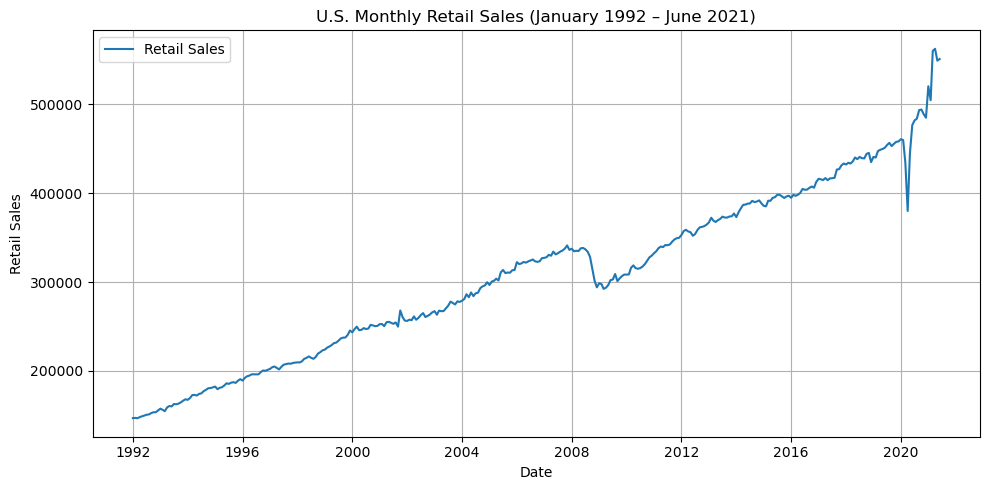

Saved: figures/us_monthly_retail_sales_trend.png


In [5]:
plt.figure(figsize=(10, 5))

plt.plot(
    sales,
    label="Retail Sales"
)

plt.title("U.S. Monthly Retail Sales (January 1992 – June 2021)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = FIGURES_DIR / "us_monthly_retail_sales_trend.png"
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/us_monthly_retail_sales_trend.png")


### Observation

- U.S. monthly retail sales show a long-term upward trend from January 1992 through June 2021.
- Strong recurring year-end sales patterns suggest clear seasonality.
- Sales decline during the 2008–2009 financial crisis and again during the 2020 COVID-19 disruption.
- The series shows a rapid recovery and sharp increase during 2021.


## 5. Create Training and Test Sets

In [6]:
sales = sales.sort_index()

train = sales.loc[:"2020-06-01"].copy()
test = sales.loc["2020-07-01":"2021-06-01"].copy()

train.index.freq = "MS"
test.index.freq = "MS"

print(
    "Training period:",
    train.index.min().strftime("%Y-%m-%d"),
    "to",
    train.index.max().strftime("%Y-%m-%d")
)

print(
    "Test period:",
    test.index.min().strftime("%Y-%m-%d"),
    "to",
    test.index.max().strftime("%Y-%m-%d")
)

print("Training size:", len(train))
print("Test size:", len(test))


Training period: 1992-01-01 to 2020-06-01
Test period: 2020-07-01 to 2021-06-01
Training size: 342
Test size: 12


### Observation

The dataset is divided chronologically so that the final 12 months are reserved for testing. The training set contains the historical data through June 2020, while the test set covers July 2020 through June 2021.


## 6. Build the SARIMA Forecasting Model

In [7]:
predictive_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = predictive_model.fit(
    disp=False
)

print("SARIMA model fitted successfully.")
print()

print("Model Performance:")
print(f"AIC: {fit.aic:.3f}")
print(f"BIC: {fit.bic:.3f}")
print(f"HQIC: {fit.hqic:.3f}")

print("\nSignificant Parameters:")
display(
    fit.pvalues[
        fit.pvalues < 0.05
    ].to_frame("p_value")
)


SARIMA model fitted successfully.

Model Performance:
AIC: 6430.359
BIC: 6449.122
HQIC: 6437.855

Significant Parameters:


,p_value
ar.L1,2.459697e-11
ma.L1,3.830145e-20
ma.S.L12,3.768812e-04
sigma2,0.000000e+00


### Observation

The SARIMA(1,1,1)(1,1,1,12) model is designed to capture both short-term time-series behavior and annual seasonality. AIC, BIC, and HQIC are reported as model-fit diagnostics, while parameter p-values help identify statistically significant model components.


## 7. Forecast the Test Period

In [8]:
forecast = fit.forecast(
    steps=len(test)
)

forecast_rounded = forecast.round(1)

forecast_results = pd.DataFrame({
    "Actual": test,
    "Predicted": forecast_rounded
})

display(forecast_results)


,Actual,Predicted
2020-07-01,481627.0,472662.2
2020-08-01,483716.0,469915.8
2020-09-01,493327.0,467295.2
2020-10-01,493991.0,469497.5
2020-11-01,488652.0,470815.3
2020-12-01,484782.0,467042.1
2021-01-01,520162.0,470290.3
2021-02-01,504458.0,469675.9
2021-03-01,559871.0,460669.6
2021-04-01,562269.0,436617.4


In [9]:
forecast_file = RESULTS_DIR / "forecast_results.csv"

forecast_results.to_csv(
    forecast_file,
    index_label="Date"
)

print("Saved: results/forecast_results.csv")


Saved: results/forecast_results.csv


## 8. Compare Actual and Predicted Retail Sales

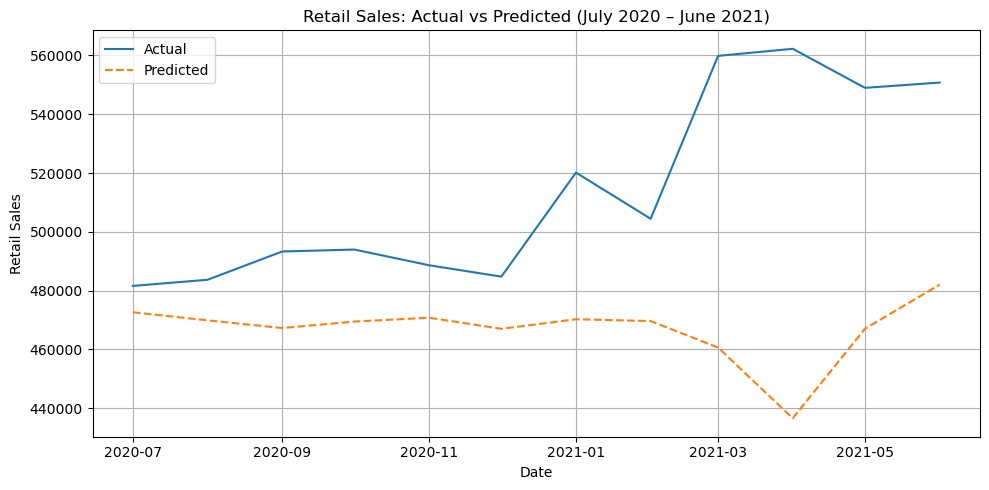

Saved: figures/actual_vs_predicted_retail_sales.png


In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    forecast,
    label="Predicted",
    linestyle="--"
)

plt.title("Retail Sales: Actual vs Predicted (July 2020 – June 2021)")
plt.xlabel("Date")
plt.ylabel("Retail Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = FIGURES_DIR / "actual_vs_predicted_retail_sales.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/actual_vs_predicted_retail_sales.png")


### Observation

The forecast generally underestimates actual retail sales during the test period, particularly during the strong rebound in 2021. This indicates that the model captures historical seasonality but has difficulty responding to a rapid structural change in the post-COVID period.


## 9. Evaluate Forecast Accuracy

In [11]:
rmse = sqrt(
    np.mean(
        (forecast - test) ** 2
    )
)

print(
    "RMSE:",
    round(rmse, 2)
)


RMSE: 59819.07


In [12]:
model_metrics = pd.DataFrame({
    "Metric": [
        "AIC",
        "BIC",
        "HQIC",
        "RMSE"
    ],
    "Value": [
        fit.aic,
        fit.bic,
        fit.hqic,
        rmse
    ]
})

model_metrics.to_csv(
    RESULTS_DIR / "model_metrics.csv",
    index=False
)

display(
    model_metrics.style.format({
        "Value": "{:,.3f}"
    })
)

print("Saved: results/model_metrics.csv")


,Metric,Value
0,AIC,"6,430.359"
1,BIC,"6,449.122"
2,HQIC,"6,437.855"
3,RMSE,"59,819.071"


Saved: results/model_metrics.csv


### Observation

The RMSE measures the average magnitude of the model's forecast error over the 12-month test period. The relatively large error reflects the model's difficulty in predicting the unusually rapid increase in retail sales during 2021.


## 10. Saved Project Outputs

In [13]:
print("Figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", f"figures/{file.name}")

print("\nResults:")
for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", f"results/{file.name}")


Figures:
 - figures/actual_vs_predicted_retail_sales.png
 - figures/us_monthly_retail_sales_trend.png

Results:
 - results/forecast_results.csv
 - results/model_metrics.csv


## Conclusion

U.S. monthly retail sales demonstrate long-term growth, recurring seasonal patterns, and noticeable disruption during major economic events. The SARIMA model successfully represents the seasonal structure of the historical series and provides a reproducible forecasting workflow.

However, the test-period results show that the model underestimates the strong sales rebound in 2021. The forecast error demonstrates the challenge of using historical time-series patterns to predict sudden structural changes. Future improvements could include parameter tuning, alternative forecasting models, external economic variables, and methods that adapt more quickly to changing trends.
